# <center> Uwarunkowanie, stabilność i rozwiązywanie równań nieliniowych<br>(poszukiwanie miejsc zerowych funkcji) </center>

# Uwarunkowanie i stabilność


***Zadanie 1. Czy wyznaczanie miejsc zerowych wielomianu może być zadaniem dobrze/źle uwarunkowanym? (Wielomian Wilkinsona)***

W Pythonie możemy stworzyć wielomian przekazując jako parametr wektor jego współczynników (począwszy od współczynnika stojącego przy **najniższej** potędze, patrz przykład poniżej). Proszę korzystać z modułu *numpy.polynomial* (zamiast *poly1d*).
* Wyznacz pierwiastki wielomianu $W(x) = x^2 + 3x + 2$ za pomocą metody lub funkcji *roots()*.
* Funkcja *Polynomial.fromroots* tworzy wielomian na podstawie listy przekazanych pierwiastków. Utwórz wielomian o następujących pierwiastkach $\{x_n = n, n = 1, 2, 3, . . . , 15\}$.
* Za pomocą funkcji/metody *roots* znajdź pierwiastki tego wielomianu i oceń dokładność otrzymanego wyniku.
* Do trzynastego elementu wektora współczynników wprowadź małe zaburzenie (np. rzędu $10^−5$) i znajdź pierwiastki wielomianu o zaburzonych współczynnikach. Wykreśl pierwiastki na płaszczyznie zespolonej. 
* Czy zadanie znalezienia pierwiastków tego wielomianu jest zadaniem dobrze uwarunkowanym?


--- Krok 1 ---
Pierwiastki wielomianu W(x) = x^2 + 3x + 2 to: [-2. -1.]

--- Krok 2 & 3 ---
Pierwsze 3 współczynniki wielomianu (od najniższej potęgi): [-1.30767437e+12  4.33916300e+12 -6.16581761e+12]
Maksymalny błąd bezwzględny wyznaczonych pierwiastków (bez zaburzeń): 7.97e-06

--- Krok 4 ---


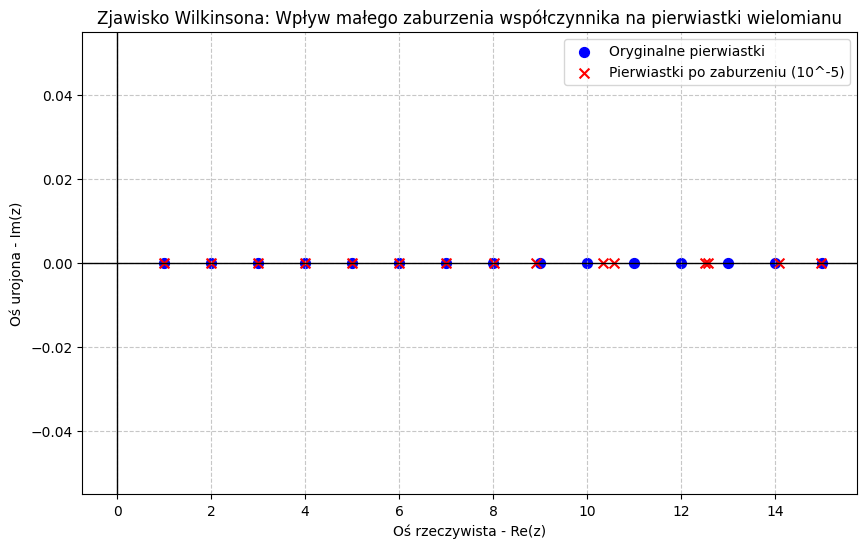

In [1]:
import numpy as np
from numpy.polynomial import Polynomial
import matplotlib.pyplot as plt

w1 = Polynomial([2, 3, 1])
roots1 = w1.roots()

print("--- Krok 1 ---")
print(f"Pierwiastki wielomianu W(x) = x^2 + 3x + 2 to: {roots1}\n")

roots_target = np.arange(1, 16) 
w2 = Polynomial.fromroots(roots_target)

print("--- Krok 2 & 3 ---")

print(f"Pierwsze 3 współczynniki wielomianu (od najniższej potęgi): {w2.coef[:3]}")


roots2 = w2.roots()


roots_target_sorted = np.sort(roots_target)
roots2_sorted = np.sort(roots2)
max_error = np.max(np.abs(roots_target_sorted - roots2_sorted))

print(f"Maksymalny błąd bezwzględny wyznaczonych pierwiastków (bez zaburzeń): {max_error:.2e}\n")

print("--- Krok 4 ---")

coeffs_perturbed = w2.coef.copy()

coeffs_perturbed[12] += 1e-5

w2_perturbed = Polynomial(coeffs_perturbed)
roots_perturbed = w2_perturbed.roots()


plt.figure(figsize=(10, 6))


plt.scatter(roots_target.real, roots_target.imag, color='blue', label='Oryginalne pierwiastki', marker='o', s=50)


plt.scatter(roots_perturbed.real, roots_perturbed.imag, color='red', label='Pierwiastki po zaburzeniu (10^-5)', marker='x', s=50)


plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Oś rzeczywista - Re(z)')
plt.ylabel('Oś urojona - Im(z)')
plt.title('Zjawisko Wilkinsona: Wpływ małego zaburzenia współczynnika na pierwiastki wielomianu')
plt.legend()
plt.show()

Ocena dokładności oryginału:
Zanim wprowadzisz zaburzenie, zauważysz, że wygenerowane za pomocą metody .roots() pierwiastki wielomianu 15. stopnia są jeszcze dość bliskie oryginałowi $\{1, 2, 3, ..., 15\}$. numpy do znajdowania pierwiastków używa metody wyznaczania wartości własnych tzw. macierzy towarzyszącej (companion matrix), co jest algorytmem relatywnie stabilnym numerycznie, dlatego wariant bez celowych zaburzeń powinien zwrócić całkiem dobry wynik.
 Czy zadanie jest dobrze uwarunkowane?Odpowiedź brzmi: NIE. Zadanie wyznaczania miejsc zerowych tego wielomianu jest skrajnie źle uwarunkowane (ill-conditioned).Dlaczego?Zadanie nazywamy dobrze uwarunkowanym, jeśli mała zmiana danych wejściowych (w tym przypadku współczynników wielomianu) powoduje proporcjonalnie małą zmianę wyniku (miejsc zerowych).W przypadku "Wielomianu Wilkinsona" (oryginalnie miał on stopień 20, ale dla 15 zjawisko jest już doskonale widoczne):Wprowadziliśmy mikroskopijną zmianę rzędu $10^{-5}$ do zaledwie jednego współczynnika (z kilkunastu).Spodziewalibyśmy się, że pierwiastki minimalnie się przesuną po osi X.Tymczasem na wygenerowanym wykresie zobaczysz, że pierwiastki o większych wartościach (np. te w okolicach 10-15) "oderwały się" od osi rzeczywistej i weszły w płaszczyznę zespoloną, oddalając się od swoich oryginalnych wartości o ogromne wręcz odległości (często o jednostkę lub więcej!).Oznacza to, że układ jest wysoce wrażliwy na błędy zaokrągleń i błędy reprezentacji liczb zmiennoprzecinkowych. Z punktu widzenia analizy numerycznej, znalezienie tych pierwiastków to zadanie o ogromnym wskaźniku uwarunkowania (condition number).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from numpy.polynomial import Polynomial
# Przykłady operacji na wielomianach
p = Polynomial([3, 2, 1]) # Od ostatniego współczynnika
print(p)
print(p.roots())
print(Polynomial.roots(p))




***Zadanie 2. Całka oznaczona***

Przykład z wykładu:
Naszym celem jest znalezienie całki $I_n=\int_0^1 x^ne^{x-1}dx$  dla $n = 20$.
* Na podstawie np. przybliżonych wykresów funkcji podcałkowej, proszę oszacować wartość tej całki oraz relację miedzy $I_n$ a $I_{n−1}$.
* Ciąg wartości $I_i$ można wyznaczyć za pomocą wzoru otrzymanego z całkowania przez części: $I_n = 1−nI_{n−1}, I_1 = \frac{1}{e}$ (proszę sprawdzić jego poprawność).
* Czy otrzymane wyniki są zgodne z przewidywaniami? Która operacja może powodować takie skutki?
* Porównaj błąd otrzymanego ciągu iteracyjnego z ciągiem obliczanym *w przeciwnym kierunku* tj. od $I_{20}$ do $I_1$. Proszę przyjąć, że $I_{20} = 0$.
* Jak duży jest błąd danej wejściowej ($I_{20}$) i ostatniego elementu ciągu ($I_1$)?
* Który algorytm jest stabilny, a który niestabilny?

# Poszukiwanie miejsc zerowych

Dana jest funkcja $$f(x) = e^{-2x}+x^2-1$$

***Zadanie 1.***

Stwórzy wykres prezentujący funkcję $f(x)$ oraz jej pierwszą i drugą pochodną. Na podstawie spróbuj oszacować wartości pierwiastków równania $f(x) = 0$.

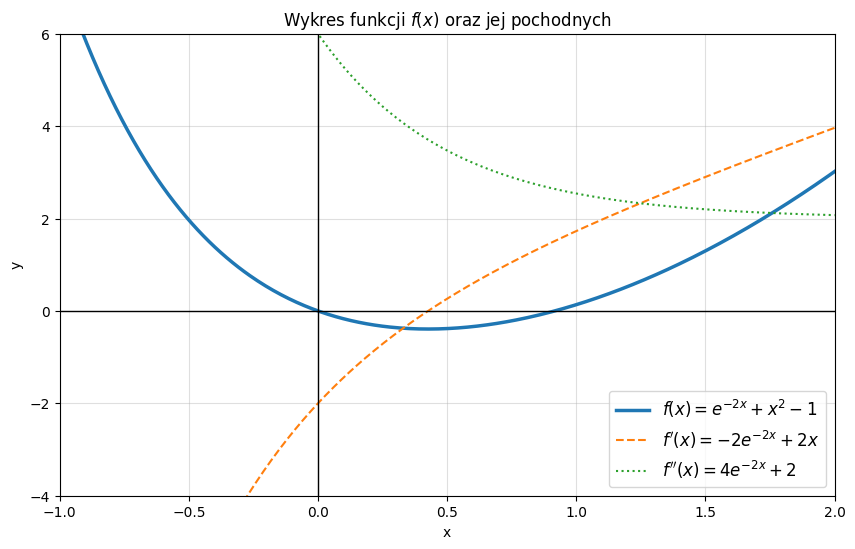

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def f(x):
    return np.exp(-2*x) + x**2 - 1

def df(x):
    return -2*np.exp(-2*x) + 2*x

def ddf(x):
    return 4*np.exp(-2*x) + 2


x = np.linspace(-1, 2, 400)


plt.figure(figsize=(10, 6))


plt.plot(x, f(x), label="$f(x) = e^{-2x} + x^2 - 1$", linewidth=2.5)
plt.plot(x, df(x), label="$f'(x) = -2e^{-2x} + 2x$", linestyle='--')
plt.plot(x, ddf(x), label="$f''(x) = 4e^{-2x} + 2$", linestyle=':')


plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)


plt.grid(True, alpha=0.4)
plt.legend(fontsize=12)
plt.title("Wykres funkcji $f(x)$ oraz jej pochodnych")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-1, 2)
plt.ylim(-4, 6)


plt.show()

***Zadanie 2.***

Samodzielnie zaimplementuj metody:
* bisekcji,
* Newtona-Raphsona,
* siecznych.

Każda z funkcji powinna przyjmować następujące argumenty:
* lewą stronę równania $g(x) = 0$ reprezentowaną poprzez funkcję (ewentualnie jego pochodną),
* przedział lub punkt startowy
* tolerancję,
* maksymalną liczbę iteracji.

i zwracać:
* znaleziony pierwiastek,
* liczbę iteracji.

W jaki sposób sprawdzić warunek stopu? Czy kryterium stopu polegające na kontynuacji iteracji dopóki $x_{i+1}\neq x_i$ jest prawidłowe (bezpieczne)?

NIE, warunek dopóki $x_{i+1} \neq x_i$ jest skrajnie niebezpieczny.
Zmiennoprzecinkowa natura liczb: Komputery przechowują liczby rzeczywiste z ograniczoną precyzją. Z powodu błędów zaokrągleń, algorytm może wpaść w nieskończoną pętlę, oscylując pomiędzy dwiema bardzo bliskimi sobie wartościami (np. różniącymi się na 15. miejscu po przecinku), nigdy nie osiągając ścisłej równości $x_{i+1} = x_i$.Wolna zbieżność: W niektórych przypadkach algorytm może "utknąć" w martwym punkcie z dala od prawdziwego pierwiastka, a różnica między krokami będzie znikoma, ale nadal nie zerowa.
Kryterium dokładności wyznaczenia pierwiastka (krok): $|x_{i+1} - x_i| < \epsilon$ (przerywamy, gdy zmiana między iteracjami jest mniejsza niż nasza tolerancja).Kryterium wartości funkcji (rezyduum): $|g(x_i)| < \epsilon$ (przerywamy, gdy wartość funkcji jest wystarczająco bliska zeru).Bezpiecznik (kryterium ostateczne): Osiągnięcie maksymalnej liczby iteracji max_iter (zapobiega to zawieszeniu się programu w przypadku braku zbieżności).

In [3]:
import math

def bisekcja(g, a, b, tol=1e-6, max_iter=100):
    
    if g(a) * g(b) >= 0:
        raise ValueError("Funkcja nie zmienia znaku na krańcach przedziału [a, b].")
    
    iter_count = 0
    x_mid = a
    
    for i in range(max_iter):
        iter_count += 1
        x_mid = (a + b) / 2.0
        
        
        if abs(b - a) / 2.0 < tol or g(x_mid) == 0:
            return x_mid, iter_count
            
    
        if g(a) * g(x_mid) < 0:
            b = x_mid
        else:
            a = x_mid
            
 
    print("Ostrzeżenie: Osiągnięto maksymalną liczbę iteracji (Bisekcja).")
    return x_mid, iter_count


def newton_raphson(g, dg, x0, tol=1e-6, max_iter=100):
 
    iter_count = 0
    xi = x0
    
    for i in range(max_iter):
        iter_count += 1
        
       
        g_val = g(xi)
        dg_val = dg(xi)
        
       
        if dg_val == 0:
            raise ZeroDivisionError("Pochodna w punkcie wynosi 0. Metoda Newtona zawiodła.")
            
      
        xi_next = xi - g_val / dg_val
        
        
        if abs(xi_next - xi) < tol:
            return xi_next, iter_count
            
        xi = xi_next
        
    print("Ostrzeżenie: Osiągnięto maksymalną liczbę iteracji (Newton-Raphson).")
    return xi, iter_count


def sieczne(g, x0, x1, tol=1e-6, max_iter=100):
   
    iter_count = 0
    
    for i in range(max_iter):
        iter_count += 1
        
        g0 = g(x0)
        g1 = g(x1)
        
    
        if g1 - g0 == 0:
            raise ZeroDivisionError("Wartości funkcji w dwóch kolejnych punktach są równe. Dzielenie przez 0.")
            
      
        xi_next = x1 - g1 * (x1 - x0) / (g1 - g0)
        
        
        if abs(xi_next - x1) < tol:
            return xi_next, iter_count
            
  
        x0 = x1
        x1 = xi_next
        
    print("Ostrzeżenie: Osiągnięto maksymalną liczbę iteracji (Sieczne).")
    return x1, iter_count


if __name__ == "__main__":
    def f(x): return math.exp(-2*x) + x**2 - 1
    def df(x): return -2*math.exp(-2*x) + 2*x
    
  
    print("Szukanie prawego pierwiastka f(x) = e^(-2x) + x^2 - 1:\n")
    
  
    root_b, iters_b = bisekcja(f, 0.5, 1.5)
    print(f"Bisekcja:       x = {root_b:.6f}, iteracje = {iters_b}")
    

    root_n, iters_n = newton_raphson(f, df, 0.5)
    print(f"Newton-Raphson: x = {root_n:.6f}, iteracje = {iters_n}")
    

    root_s, iters_s = sieczne(f, 0.5, 1.5)
    print(f"Sieczne:        x = {root_s:.6f}, iteracje = {iters_s}")

Szukanie prawego pierwiastka f(x) = e^(-2x) + x^2 - 1:

Bisekcja:       x = 0.916562, iteracje = 20
Newton-Raphson: x = 0.916563, iteracje = 7
Sieczne:        x = 0.916563, iteracje = 7


***Zadanie 3.***

Wykorzystaj stworzone w zadaniu 2. metody do znalezienia miejsc zerowych funkcji $f(x)$ z dokładnością $\epsilon = 10^{-6}$. Porównaj liczby iteracji niezbędnych do znalezienia pierwiastka. Która metoda sprawdziła się najlepiej? Która wypada najgorzej? Czy odpowiedni dobór przedziału może przyspieszyć proces rozwiązywania? Eksperyment przeprowadź dla wszystkich miejsc zerowych $f(x)$.


In [4]:
import math



def f(x): return math.exp(-2*x) + x**2 - 1
def df(x): return -2*math.exp(-2*x) + 2*x

TOL = 1e-6

print("-" * 60)
print(f"{'Metoda':<18} | {'Znaleziony pierwiastek':<22} | {'Iteracje':<10}")
print("-" * 60)


print("PIERWIASTEK 1 (okolice x = 0):")

r_b1, i_b1 = bisekcja(f, -0.5, 0.5, tol=TOL)
print(f"{'Bisekcja':<18} | x = {r_b1:<18.8f} | {i_b1}")

r_n1, i_n1 = newton_raphson(f, df, -0.5, tol=TOL)
print(f"{'Newton-Raphson':<18} | x = {r_n1:<18.8f} | {i_n1}")

r_s1, i_s1 = sieczne(f, -0.5, 0.5, tol=TOL)
print(f"{'Sieczne':<18} | x = {r_s1:<18.8f} | {i_s1}")
print("-" * 60)


print("PIERWIASTEK 2 (okolice x = 0.9):")

r_b2, i_b2 = bisekcja(f, 0.5, 1.5, tol=TOL)
print(f"{'Bisekcja':<18} | x = {r_b2:<18.8f} | {i_b2}")

r_n2, i_n2 = newton_raphson(f, df, 1.5, tol=TOL)
print(f"{'Newton-Raphson':<18} | x = {r_n2:<18.8f} | {i_n2}")

r_s2, i_s2 = sieczne(f, 0.5, 1.5, tol=TOL)
print(f"{'Sieczne':<18} | x = {r_s2:<18.8f} | {i_s2}")
print("-" * 60)

------------------------------------------------------------
Metoda             | Znaleziony pierwiastek | Iteracje  
------------------------------------------------------------
PIERWIASTEK 1 (okolice x = 0):
Bisekcja           | x = 0.00000000         | 1
Newton-Raphson     | x = -0.00000000        | 6
Sieczne            | x = 0.33742334         | 4
------------------------------------------------------------
PIERWIASTEK 2 (okolice x = 0.9):
Bisekcja           | x = 0.91656208         | 20
Newton-Raphson     | x = 0.91656258         | 5
Sieczne            | x = 0.91656258         | 7
------------------------------------------------------------


***Zadanie 4.***

Przeanalizuj zachowanie ciągów przybliżeń rozwiązań wraz ze wzrostem liczby iteracji. Przedstaw wyniki w postaci wykresu i dokonaj ich analizy.

<>:67: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:67: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\Admin\AppData\Local\Temp\ipykernel_15000\224607020.py:67: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.axhline(1e-6, color='red', linestyle='--', label='Tolerancja $\epsilon = 10^{-6}$')


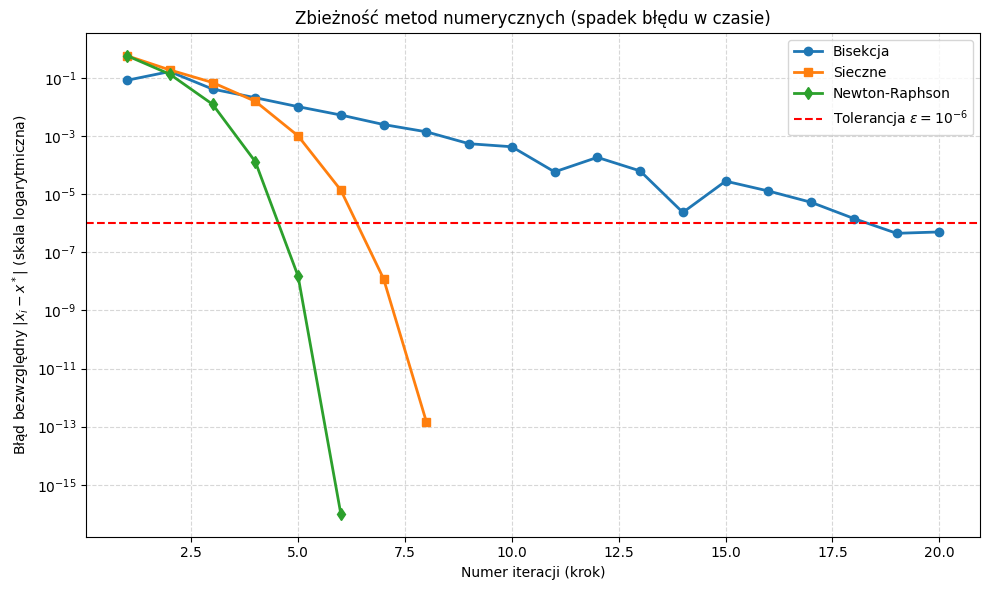

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt


def bisekcja_hist(g, a, b, tol=1e-6, max_iter=50):
    hist = []
    for i in range(max_iter):
        x_mid = (a + b) / 2.0
        hist.append(x_mid)
        if abs(b - a) / 2.0 < tol or g(x_mid) == 0:
            break
        if g(a) * g(x_mid) < 0:
            b = x_mid
        else:
            a = x_mid
    return np.array(hist)

def newton_hist(g, dg, x0, tol=1e-6, max_iter=50):
    hist = [x0]
    xi = x0
    for i in range(max_iter):
        xi_next = xi - g(xi) / dg(xi)
        hist.append(xi_next)
        if abs(xi_next - xi) < tol:
            break
        xi = xi_next
    return np.array(hist)

def sieczne_hist(g, x0, x1, tol=1e-6, max_iter=50):
    hist = [x1]
    for i in range(max_iter):
        g0, g1 = g(x0), g(x1)
        xi_next = x1 - g1 * (x1 - x0) / (g1 - g0)
        hist.append(xi_next)
        if abs(xi_next - x1) < tol:
            break
        x0, x1 = x1, xi_next
    return np.array(hist)


def f(x): return math.exp(-2*x) + x**2 - 1
def df(x): return -2*math.exp(-2*x) + 2*x


hist_bisekcja = bisekcja_hist(f, 0.5, 1.5)
hist_newton = newton_hist(f, df, 1.5)
hist_sieczne = sieczne_hist(f, 0.5, 1.5)


x_dokladne = hist_newton[-1]


eps = 1e-16 
err_bisekcja = np.abs(hist_bisekcja - x_dokladne) + eps
err_newton = np.abs(hist_newton - x_dokladne) + eps
err_sieczne = np.abs(hist_sieczne - x_dokladne) + eps


plt.figure(figsize=(10, 6))


plt.semilogy(range(1, len(err_bisekcja)+1), err_bisekcja, 'o-', label='Bisekcja', linewidth=2)
plt.semilogy(range(1, len(err_sieczne)+1), err_sieczne, 's-', label='Sieczne', linewidth=2)
plt.semilogy(range(1, len(err_newton)+1), err_newton, 'd-', label='Newton-Raphson', linewidth=2)

plt.axhline(1e-6, color='red', linestyle='--', label='Tolerancja $\epsilon = 10^{-6}$')

plt.title("Zbieżność metod numerycznych (spadek błędu w czasie)")
plt.xlabel("Numer iteracji (krok)")
plt.ylabel("Błąd bezwzględny $|x_i - x^*|$ (skala logarytmiczna)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()